# Projeto IACH

**Aplicação do sistema de recomendações de músicas**

### 1 - Configuração e análise exploratória dos dados

**Imports**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import re
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics, preprocessing

from tensorflow.keras import models, layers, utils # type: ignore #(2.6.0)

**Tratamento do dataset das músicas**

In [2]:
dtf_products = pd.read_csv("musics_f.csv")

dtf_products["product"] = range(0,len(dtf_products))

dtf_products["old"] = dtf_products["Year"].apply(lambda x: 1 if x < 2000 else 0)

dtf_products

,musicId,name,genres,Year,rating,product,old
0,69073,I Won't Wake up This Time (Freaks),anime|chill|comedy|happy|new-age|romance|sad|s...,2010,2.80,0,0
1,44778,かべの人,ambient|idm|minimal-techno|trip-hop,1998,0.55,1,1
2,16472,Devotion,chicago-house|club|dance|dancehall|garage|house,2017,2.30,2,0
3,67183,The Locomotion,album rock|classic rock|hard-rock|rock|rock-n-...,1981,3.05,3,1
4,46700,Tanz Schlampe,alternative metal|black-metal|death-metal|grin...,2008,1.35,4,0
...,...,...,...,...,...,...,...
2495,78415,En Un Bondi Color Humo,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...,1969,1.05,2495,1
2496,3740,Talkatif,afrobeat|dancehall|dub|reggae|ska,2007,0.80,2496,0
2497,25699,Let You Go,afrobeat|dancehall|dub|reggae|ska,1979,2.25,2497,1
2498,2306,Leave The Lights On,acoustic|country|folk|honky-tonk|singer-songwr...,1987,2.80,2498,1


**Gráfico de barras com count dos anos das músicas**

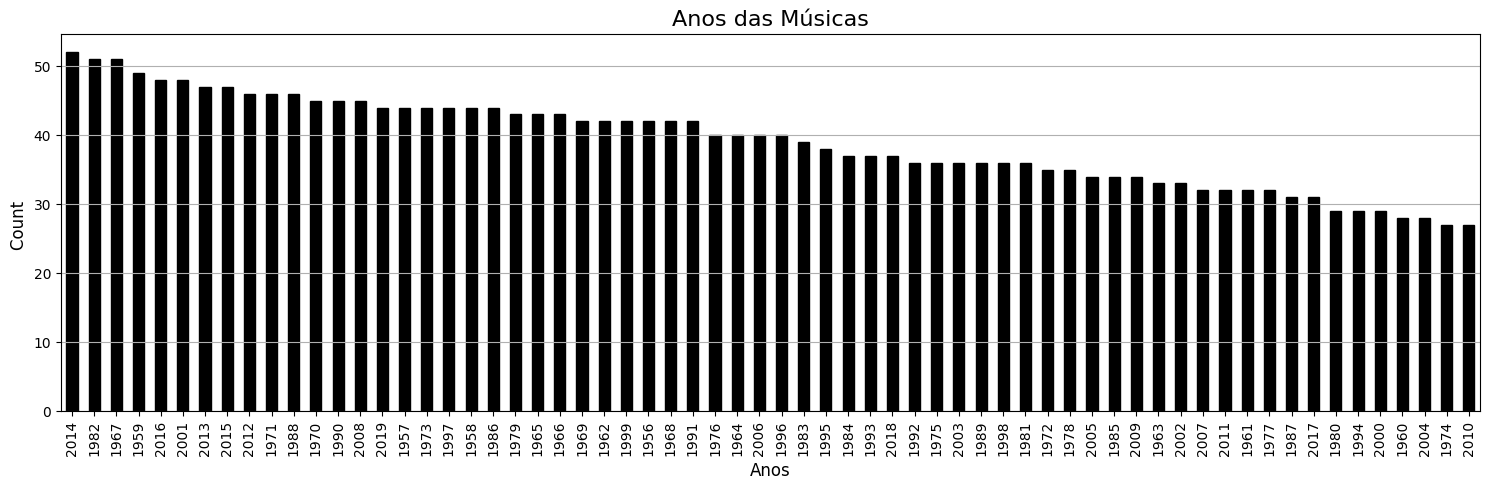

Quantidade de anos únicos:
64


In [3]:
genre_counts = dtf_products['Year'].value_counts()

plt.figure(figsize=(15, 5))
genre_counts.plot(kind='bar', color='black', edgecolor='black')
plt.title('Anos das Músicas', fontsize=16)
plt.xlabel('Anos', fontsize=12)
plt.ylabel('Count ', fontsize=12)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print('Quantidade de anos únicos:')
print(len(dtf_products['Year'].unique()))

**Tratamento do dataset dos users**

In [4]:
dtf_users = pd.read_csv("users_f.csv")

dtf_users["user"] = dtf_users["userId"].apply(lambda x: x-1)

dtf_users["timestamp"] = dtf_users["timestamp"].apply(lambda x: datetime.fromtimestamp(x))
dtf_users["daytime"] = dtf_users["timestamp"].apply(lambda x: 1 if 6<int(x.strftime("%H"))<20 else 0)
dtf_users["weekend"] = dtf_users["timestamp"].apply(lambda x: 1 if x.weekday() in [5,6] else 0)

dtf_users = dtf_users.merge(dtf_products[["musicId","product"]], how="left")
dtf_users = dtf_users.rename(columns={"rating":"y"})

dtf_users

,userId,musicId,y,timestamp,user,daytime,weekend,product
0,1,2632,2.65,2023-05-21 07:11:29,0,1,1,1140
1,1,18880,2.10,2023-02-08 20:32:14,0,0,0,1714
2,1,82051,2.45,2023-12-21 15:20:53,0,1,0,2155
3,1,2077,2.90,2023-10-05 02:51:19,0,0,0,1039
4,1,2315,2.80,2023-05-22 13:08:41,0,1,0,1863
...,...,...,...,...,...,...,...,...
189525,500,40571,1.50,2023-04-25 07:16:18,499,1,0,21
189526,500,20943,2.55,2023-05-01 23:09:37,499,0,0,699
189527,500,55780,3.10,2023-07-12 12:25:43,499,1,0,1168
189528,500,46545,3.35,2023-02-26 05:14:32,499,0,1,1999


**Criação do dataframe dos products**

In [5]:
dtf_products = dtf_products[["product","name","old","genres"]].set_index("product")
dtf_products.head()

,name,old,genres
product,,,
0,I Won't Wake up This Time (Freaks),0,anime|chill|comedy|happy|new-age|romance|sad|s...
1,かべの人,1,ambient|idm|minimal-techno|trip-hop
2,Devotion,0,chicago-house|club|dance|dancehall|garage|house
3,The Locomotion,1,album rock|classic rock|hard-rock|rock|rock-n-...
4,Tanz Schlampe,0,alternative metal|black-metal|death-metal|grin...


**Criação de um dataframe de tempo em relação aos products**

In [6]:
dtf_context = dtf_users[["user","product","daytime","weekend"]]
dtf_context.head()

,user,product,daytime,weekend
0,0,1140,1,1
1,0,1714,0,0
2,0,2155,1,0
3,0,1039,0,0
4,0,1863,1,0


**Criação de um dataframe que relaciona o rating do user com a música**

In [7]:
dtf_users = dtf_users[["user","product","y"]]
dtf_users

,user,product,y
0,0,1140,2.65
1,0,1714,2.10
2,0,2155,2.45
3,0,1039,2.90
4,0,1863,2.80
...,...,...,...
189525,499,21,1.50
189526,499,699,2.55
189527,499,1168,3.10
189528,499,1999,3.35


**Gráfico de barras com count de géneros**

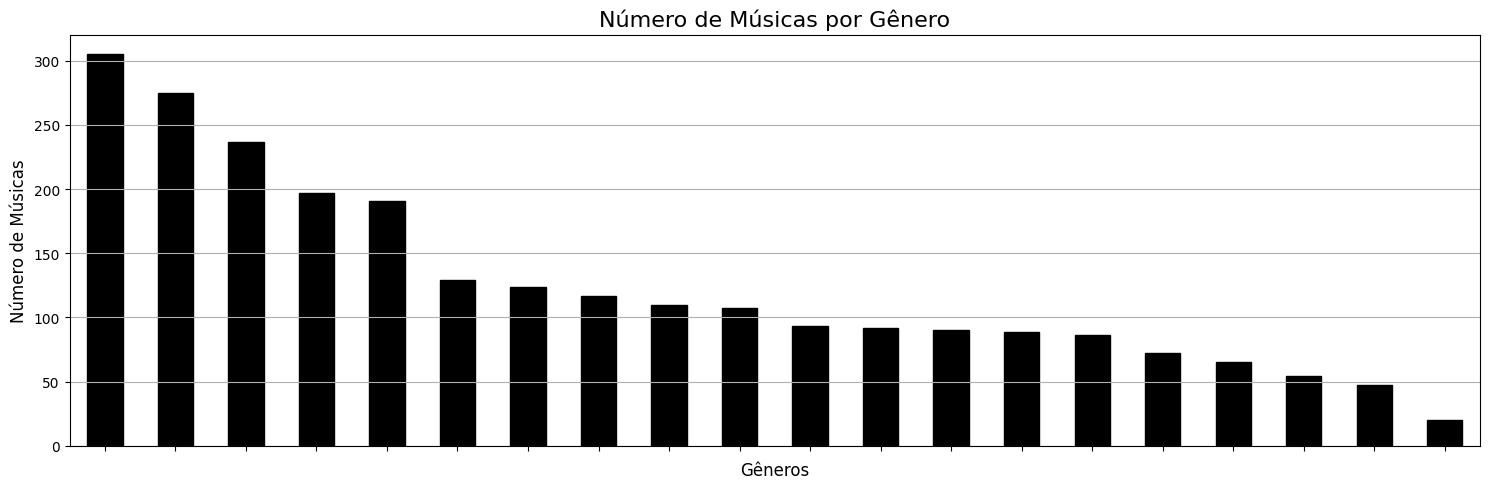

20


In [8]:
genre_counts = dtf_products['genres'].value_counts()

plt.figure(figsize=(15, 5))
genre_counts.plot(kind='bar', color='black', edgecolor='black')
plt.title('Número de Músicas por Gênero', fontsize=16)
plt.gca().set_xticklabels([])
plt.xlabel('Gêneros', fontsize=12)
plt.ylabel('Número de Músicas', fontsize=12)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print(len(dtf_products['genres'].unique()))

**Divisão dos géneros criando uma matriz músicas por género independente**

In [9]:
tags = [i.split("|") for i in dtf_products["genres"].unique()]
columns = list(set([i for lst in tags for i in lst]))
print(columns)

['happy', 'dance rock', 'dutch cabaret', 'goth', 'dance pop', 'r-n-b', 'latin', 'hard-rock', 'guitar', 'classic rock', 'k-pop', 'bluegrass', 'opera', 'children', 'pop', 'jazz', 'rockabilly', 'psych-rock', 'acoustic', 'progressive-house', 'cantopop', 'sleep', 'ska', 'french', 'industrial', 'singer-songwriter', 'german', 'idm', 'chill', 'detroit-techno', 'dutch pop', 'folk', 'spanish', 'sertanejo', 'minimal-techno', 'deep-house', 'emo', 'anime', 'alternative rock', 'electro', 'grunge', 'techno', 'j-idol', 'malay', 'house', 'dancehall', 'country', 'blues', 'j-pop', 'j-rock', 'indian', 'swedish', 'new-age', 'turkish', 'honky-tonk', 'dutch indie', 'edm', 'funk', 'chicago-house', 'ambient', 'hardstyle', 'garage', 'power-pop', 'punk', 'indie-pop', 'pop-film', 'dance', 'drum-and-bass', 'metalcore', 'disco', 'kids', 'tango', 'samba', 'j-dance', 'afrobeat', 'disney', 'iranian', 'rap', 'punk-rock', 'reggaeton', 'soul', 'british', 'alt-rock', 'dubstep', 'show-tunes', 'death-metal', 'groove', 'forr

In [10]:
for col in columns:
    dtf_products[col] = dtf_products["genres"].apply(lambda x: 1 if col in x else 0)
dtf_products.head()

,name,old,genres,happy,dance rock,dutch cabaret,goth,dance pop,r-n-b,latin,...,romance,salsa,heavy-metal,piano,comedy,club,album rock,party,sad,synth-pop
product,,,,,,,,,,,,,,,,,,,,,
0,I Won't Wake up This Time (Freaks),0,anime|chill|comedy|happy|new-age|romance|sad|s...,1,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,1,0
1,かべの人,1,ambient|idm|minimal-techno|trip-hop,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Devotion,0,chicago-house|club|dance|dancehall|garage|house,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,The Locomotion,1,album rock|classic rock|hard-rock|rock|rock-n-...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,Tanz Schlampe,0,alternative metal|black-metal|death-metal|grin...,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


**Heatmap música por género independente**

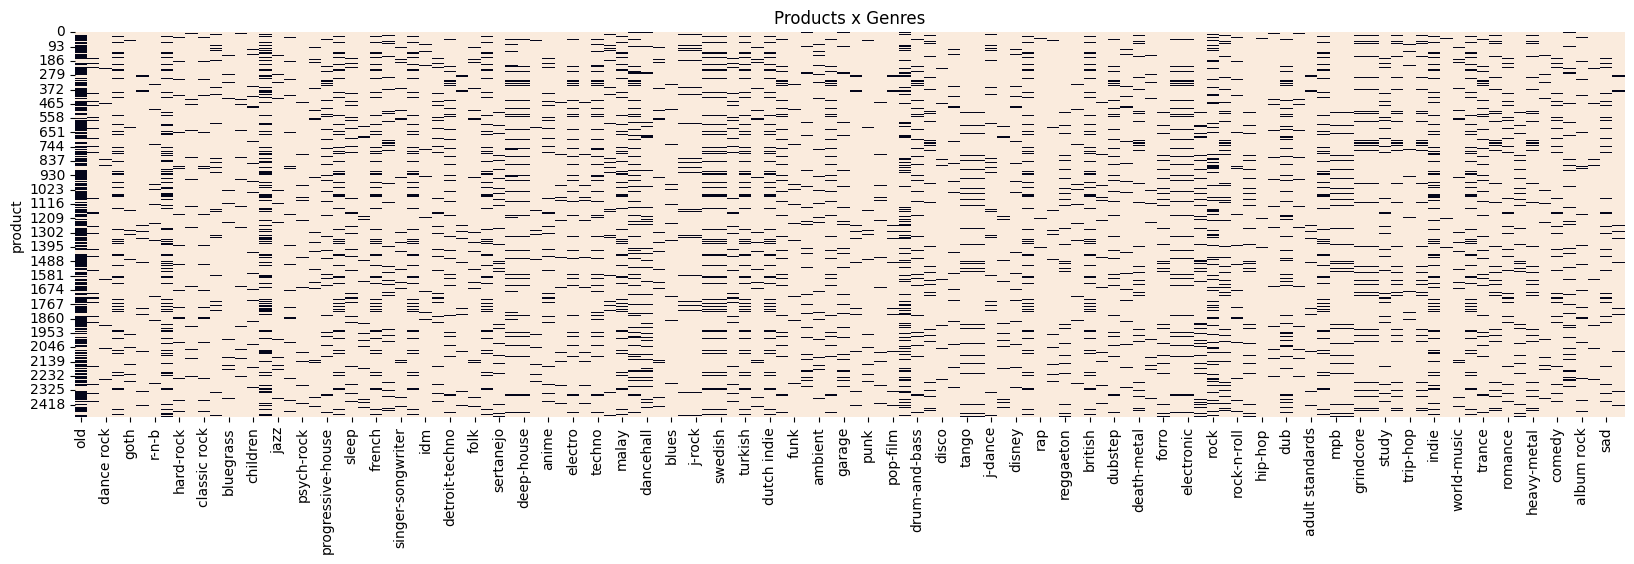

In [11]:
dtf_temp = dtf_products.drop(columns=["name", "genres"])
fig, ax = plt.subplots(figsize=(20,5))
sns.heatmap(dtf_temp==0, vmin=0, vmax=1, cbar=False, ax=ax).set_title("Products x Genres")
plt.show()

**Gráfico de barras com count de músicas ouvidas por user e sua análise**

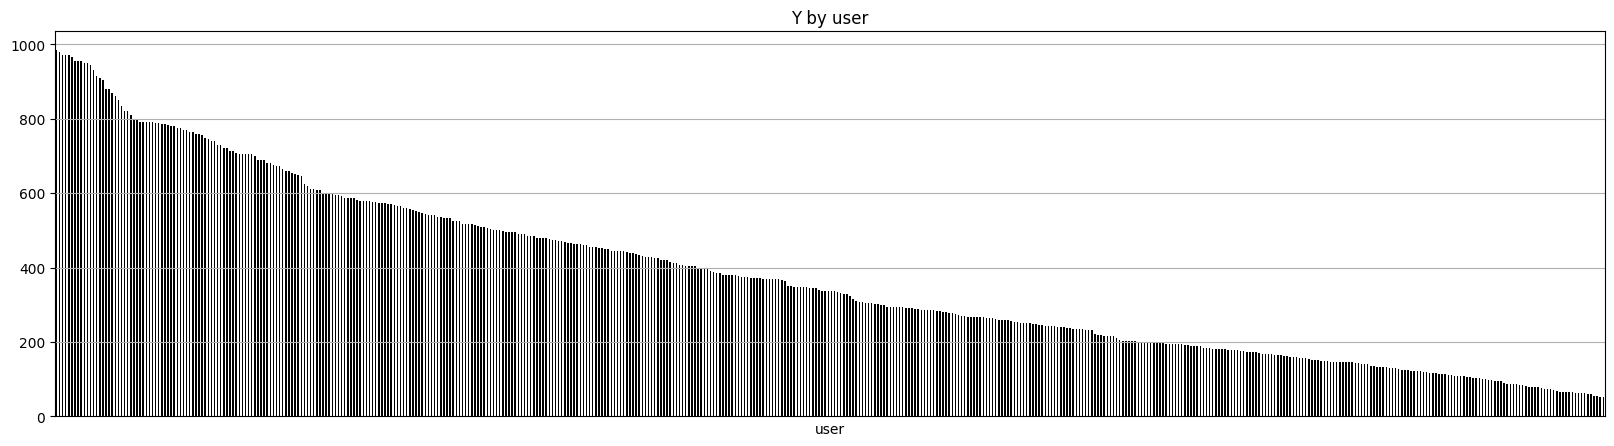

In [12]:
dtf_users.groupby("user").count()["product"].sort_values(ascending=False).plot(
    kind="bar",xticks=[], color="black", title="Y by user", figsize=(20,5)).grid(axis='y')

In [13]:
genre_counts = dtf_users['user'].value_counts()
max_user = genre_counts.max()
min_user = genre_counts.min()
mean_user = round(genre_counts.mean())

print(f'Máximo número de registros por usuário: {max_user}')
print(f'Mínimo número de registros por usuário: {min_user}')
print(f'Média de registros por usuário: {mean_user}')

print()


users_max = genre_counts[genre_counts == max_user].index.tolist()
print(f'Usuários com o máximo número de registros ({max_user}): {users_max}')

users_max_aux = users_max[0]

users_min = genre_counts[genre_counts == min_user].index.tolist()
print(f'Usuários com o mínimo número de registros ({min_user}): {users_min}')

users_mean = genre_counts[genre_counts == mean_user].index.tolist()
print(f'Usuários com o número de registros igual à média ({mean_user}): {users_mean}')

Máximo número de registros por usuário: 985
Mínimo número de registros por usuário: 51
Média de registros por usuário: 379

Usuários com o máximo número de registros (985): [31]
Usuários com o mínimo número de registros (51): [120, 454]
Usuários com o número de registros igual à média (379): []


**Gráfico de barras com count de ratings de todos os users**

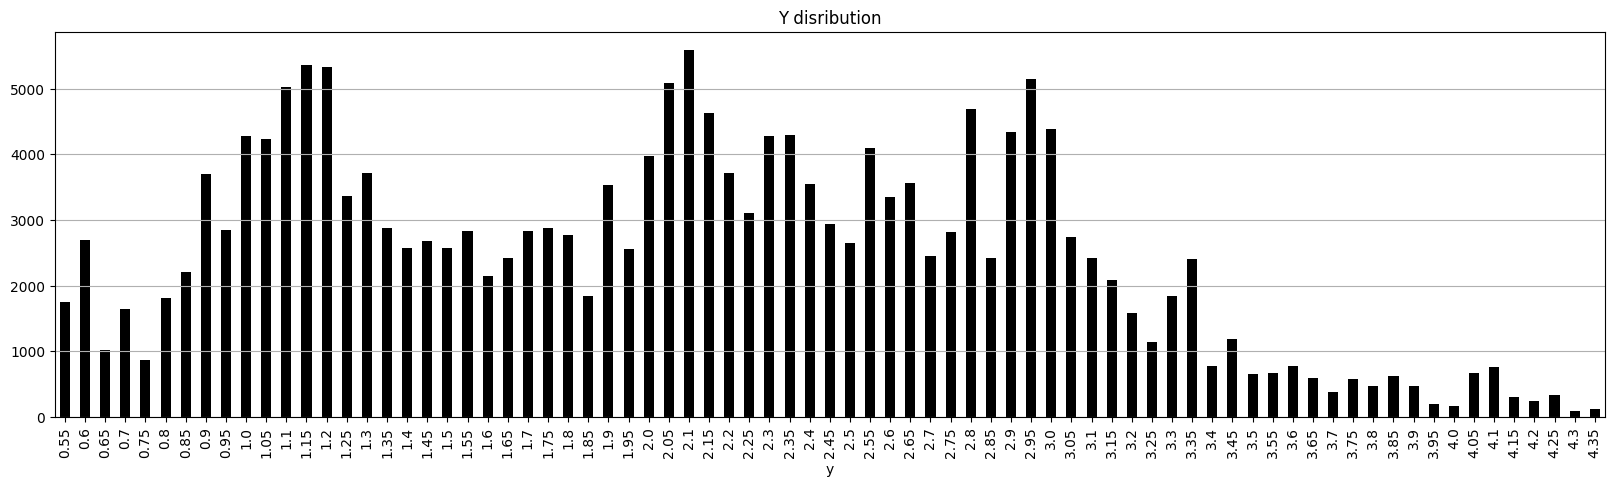

In [14]:
dtf_users["y"].value_counts().sort_index().plot(kind="bar", color="black", title="Y disribution", 
                                                figsize=(20,5)).grid(axis='y')
plt.show()

**Criação de tabela do rating de cada user por cada música ouvida**

In [15]:
tmp = dtf_users.copy()
dtf_users = tmp.pivot_table(index="user", columns="product", values="y")
#all_columns = set(dtf_products.index)
#dtf_users = dtf_users.reindex(columns=all_columns)
#dtf_users = dtf_users.assign(**{str(col): np.nan for col in missing_cols})
missing_cols = list(set(dtf_products.index) - set(dtf_users.columns))

for col in missing_cols:
    dtf_users[col] = np.nan


dtf_users = dtf_users[sorted(dtf_users.columns)]
dtf_users

product,0,1,2,3,4,5,6,7,8,9,...,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499
user,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,NaN,NaN,NaN,NaN,NaN,NaN,2.35,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Heatmap da tabela anterior**

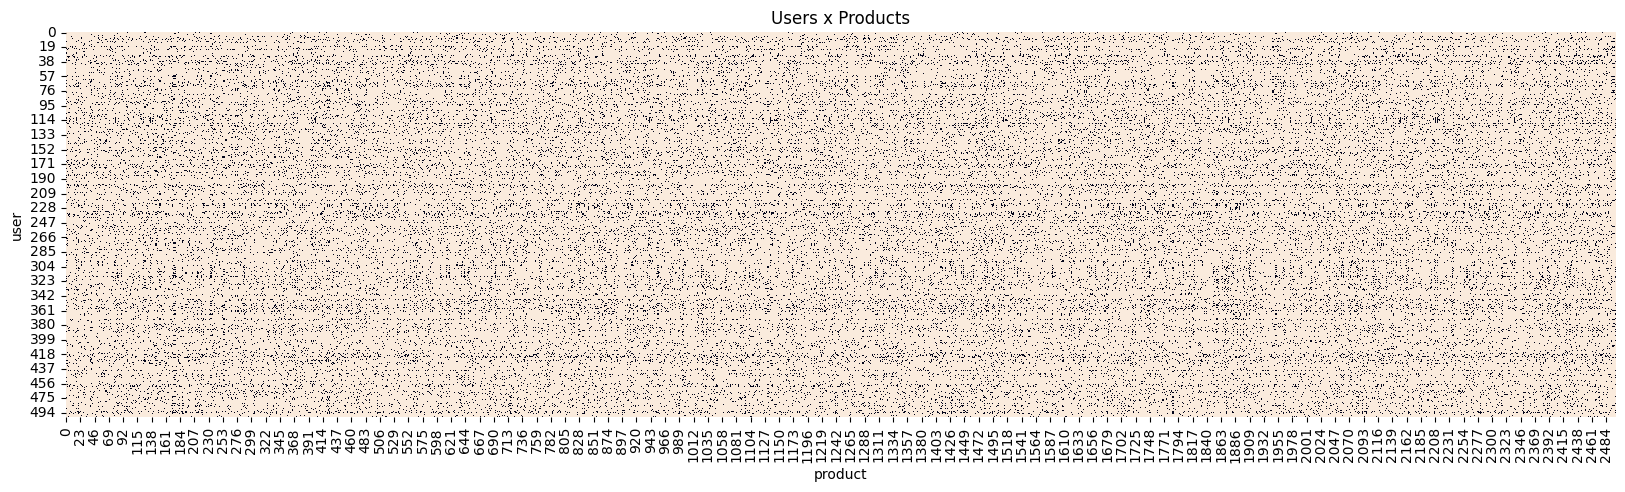

In [16]:
fig, ax = plt.subplots(figsize=(20,5))
sns.heatmap(dtf_users.isnull(), vmin=0, vmax=1, cbar=False, ax=ax).set_title("Users x Products")
plt.show()

**Análise do count do tempo de todas as músicas**

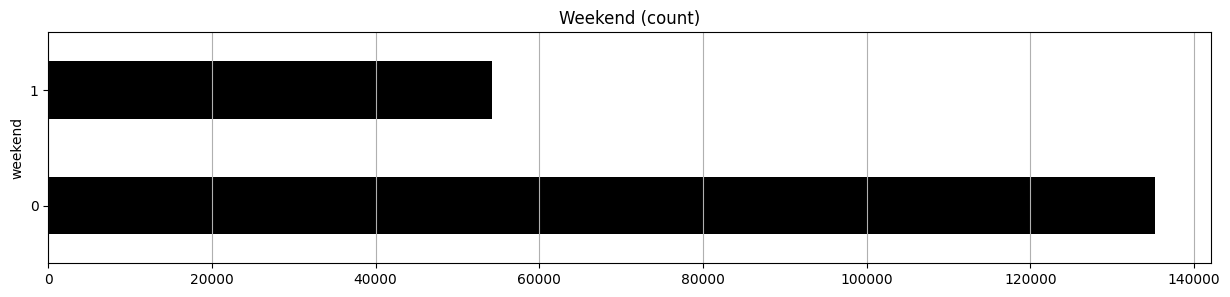

In [17]:
dtf_context["weekend"].value_counts().plot(kind="barh", color="black", title="Weekend (count)", 
                                         figsize=(15,3)).grid(axis='x')
plt.show()

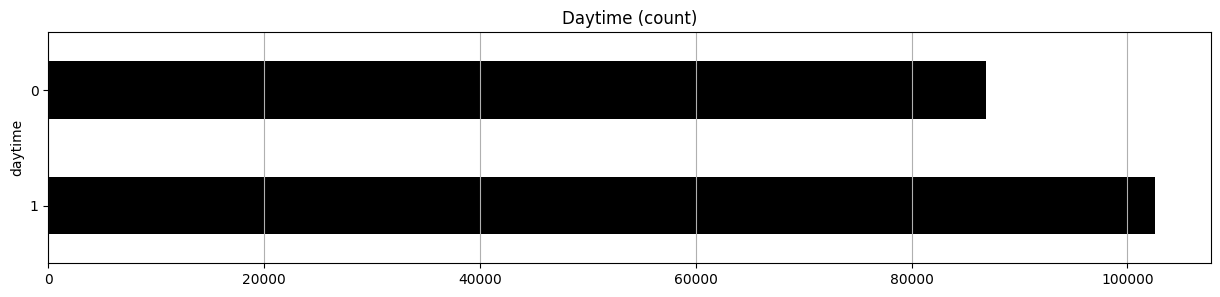

In [18]:
dtf_context["daytime"].value_counts().plot(kind="barh", color="black", title="Daytime (count)", 
                                         figsize=(15,3)).grid(axis='x')
plt.show()

### 2 - Preprocessing

**Scaling**

In [19]:
dtf_users = pd.DataFrame(preprocessing.MinMaxScaler(feature_range=(0.5,1)).fit_transform(dtf_users.values), 
                         columns=dtf_users.columns, index=dtf_users.index)
dtf_users

product,0,1,2,3,4,5,6,7,8,9,...,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499
user,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Particionamento**

In [20]:
split = int(0.8*dtf_users.shape[1])
split

2000

**Treino**

In [21]:
dtf_train = dtf_users.loc[:, :split-1]
print("non-null data:", dtf_train[dtf_train>0].count().sum())
dtf_train

non-null data: 80654


product,0,1,2,3,4,5,6,7,8,9,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
user,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN
497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Teste**

In [22]:
dtf_test = dtf_users.loc[:, split:]
print("non-null data:", dtf_test[dtf_test>0].count().sum())
dtf_test

non-null data: 20498


product,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2490,2491,2492,2493,2494,2495,2496,2497,2498,2499
user,,,,,,,,,,,,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.5,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
496,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
497,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Aplicação dos modelos

### 3 - Baseline (Content-Based)

In [23]:
# Select a user - usar 0,995,68
i = users_max_aux
train = dtf_train.iloc[i].to_frame(name="y")
test = dtf_test.iloc[i].to_frame(name="y")

print("train:", len(train[~train["y"].isna()]), "| test:", len(test[~test["y"].isna()]))
x_value = len(test[~test["y"].isna()])+1
test.head()

train: 379 | test: 96


,y
product,
2000,NaN
2001,NaN
2002,NaN
2003,NaN
2004,NaN


**Adicione todos os produtos num teste mas vazio**

In [24]:
tmp = test.copy()
tmp["y"] = np.nan
train = pd.concat([train, tmp], ignore_index=True)
train.tail()

,y
2495,NaN
2496,NaN
2497,NaN
2498,NaN
2499,NaN


**Modelo**

In [25]:
usr = train[["y"]].fillna(0).values.T
prd = dtf_products.drop(["name","genres"],axis=1).values
print("Users", usr.shape, " x  Products", prd.shape)

Users (1, 2500)  x  Products (2500, 126)


**Treino e Teste**

In [26]:
## usr_ft(users,fatures) = usr(users,products) x prd(products,features)
usr_ft = np.dot(usr, prd)

## normalize
weights = usr_ft / usr_ft.sum()

## predicted rating(users,products) = weights(users,fatures) x prd.T(features,products)
pred = np.dot(weights, prd.T)

test = test.merge(pd.DataFrame(pred[0], columns=["yhat"]), how="left", left_index=True, right_index=True).reset_index()
test = test[~test["y"].isna()]
test_len = round((len(test[~test["y"].isna()]))/2)
test

,product,y,yhat
8,2008,0.5,0.366358
20,2020,0.5,0.418519
21,2021,0.5,0.418519
32,2032,0.5,0.142901
48,2048,0.5,0.135185
...,...,...,...
473,2473,0.5,0.142901
475,2475,0.5,0.336111
479,2479,0.5,0.283951
481,2481,0.5,0.366358


**Função de Avaliação**

In [27]:
def mean_reciprocal_rank(y_test, predicted): # Diferença entre os valores testados e os predicted
    score = []
    for product in y_test:
        mrr = 1 / (list(predicted).index(product) + 1) if product in predicted else 0
        score.append(mrr)
    return np.mean(score)

**Criação de métricas de avalição com diferentes tamanhos de y_test e predicted, num user em específico**

In [28]:
print("--- user", i, "---")

lA=[]
lR=[]
lP=[]
lrr=[]

x=range(1,x_value)

for j in x:
    top = j
    y_test = test.sort_values("y", ascending=False)["product"].values[:top]
    #print("y_test:", y_test)

    predicted = test.sort_values("yhat", ascending=False)["product"].values[:top]
    #print("predicted:", predicted)

    y_test_set = set(y_test)
    predicted_set = set(predicted)

    true_positive = len(y_test_set & predicted_set)

    false_negative = len(y_test_set - predicted_set)

    false_positive = len(predicted_set - y_test_set)

    #Accuracy
    accuracy = (true_positive / top)*100

    # Recall
    recall = (true_positive / (true_positive + false_negative))*100

    # Precision
    precision = true_positive / (true_positive + false_positive)*100

    lA.append(accuracy)
    lR.append(recall)
    lP.append(precision)
    lrr.append(round(mean_reciprocal_rank(y_test, predicted),2))

    if accuracy == 100:
        if recall == 100:
            if precision == 100:
                print('Valor que chegou a 100%: '+str(j))

def accVM():
    top = test_len
    y_test = test.sort_values("y", ascending=False)["product"].values[:top]
    predicted = test.sort_values("yhat", ascending=False)["product"].values[:top]
    y_test_set = set(y_test)
    predicted_set = set(predicted)
    true_positive = len(y_test_set & predicted_set)
    accuracyVM = (true_positive / top)*100
    print("accuracy do valor médio de x:",str(round(accuracyVM,2))+'%')
    return accuracyVM,top

print("accuracy:", str(round(metrics.accuracy_score(y_test,predicted)*100,2))+"%")
accuracyVM,top = accVM()
print("Mrr:", round(mean_reciprocal_rank(y_test, predicted),2))

--- user 31 ---
Valor que chegou a 100%: 96
accuracy: 0.0%
accuracy do valor médio de x: 54.17%
Mrr: 0.05


**Resultados obtidos do Baseline (Content-Based)**

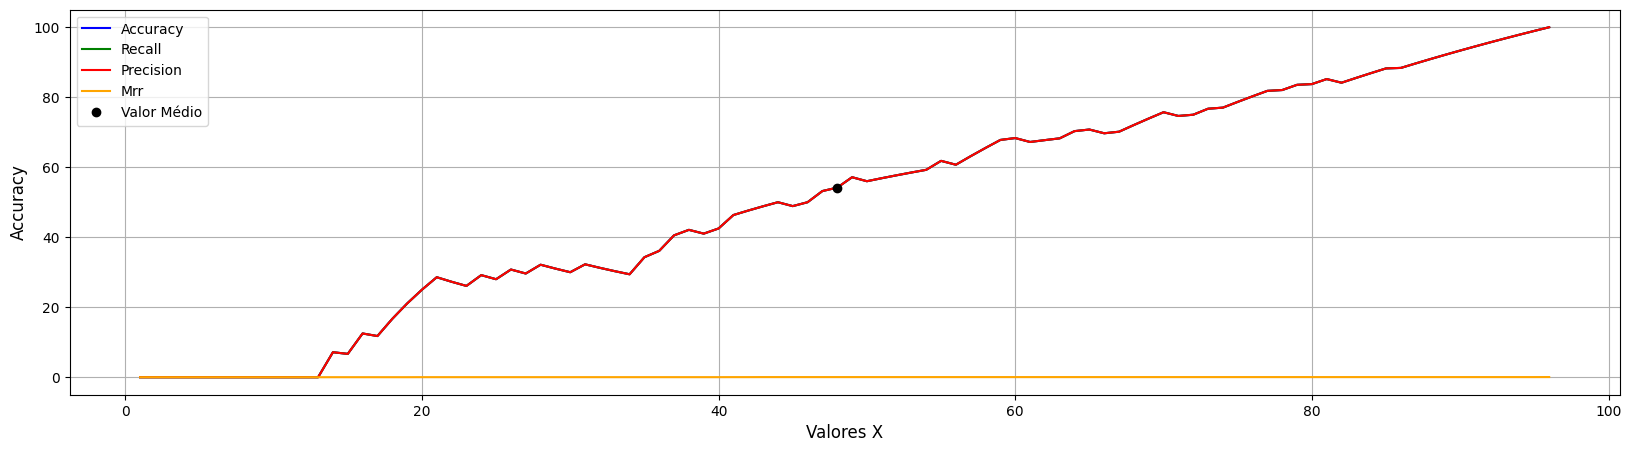

In [29]:
plt.figure(figsize=(20, 5))
plt.plot(x, lA, label="Accuracy", color="blue")  
plt.plot(x, lR, label="Recall", color="green")  
plt.plot(x, lP, label="Precision", color="red")   
plt.plot(x, lrr, label="Mrr", color="orange")
plt.plot(top,accuracyVM,'bo',color='black',label="Valor Médio")
plt.xlabel("Valores X", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y')
plt.grid(axis='x')
plt.legend()
plt.show()

**Identificação das músicas e respetivas informações**

In [30]:
test.merge(
        dtf_products[["name","old","genres"]], left_on="product", right_index=True
    ).sort_values("yhat", ascending=False)

,product,y,yhat,name,old,genres
495,2495,0.5,0.418519,En Un Bondi Color Humo,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
433,2433,0.5,0.418519,Si Te Dijeron,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
216,2216,0.5,0.418519,Princesa,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
144,2144,0.5,0.418519,Folha De Bananeira,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
245,2245,0.5,0.418519,Terminar na Cama,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
...,...,...,...,...,...,...
207,2207,0.5,0.060494,I Will Follow You,0,blues|funk|r-n-b|soul
97,2097,0.5,0.060494,Little Drummer Boy,0,blues|funk|r-n-b|soul
281,2281,0.5,0.060494,Olha A Explosão,0,blues|funk|r-n-b|soul
389,2389,0.5,0.060494,Ay Que Borrachera,0,blues|funk|r-n-b|soul


**Gráfico de análise do rating real com o previsto**

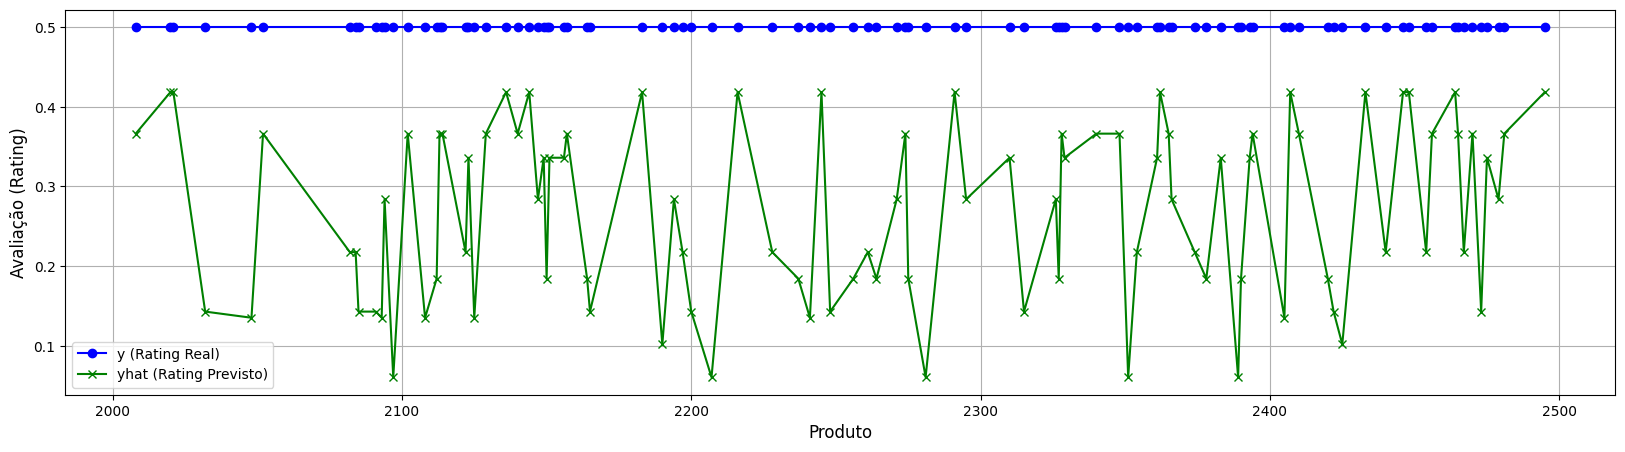

In [31]:
plt.figure(figsize=(20, 5))
plt.plot(test['product'], test['y'], label='y (Rating Real)', color="blue", marker='o')
plt.plot(test['product'], test['yhat'], label='yhat (Rating Previsto)', color="green", marker='x')
plt.xlabel("Produto", fontsize=12)
plt.ylabel("Avaliação (Rating)", fontsize=12)
plt.grid()
plt.legend()
plt.show()

### 4 - Model Desing & Testing (Collaborative Filtering)

**Data**

In [32]:
train = dtf_train.stack(dropna=True).reset_index().rename(columns={0:"y"})
train.head()

,user,product,y
0,0,11,0.5
1,0,45,0.5
2,0,90,0.5
3,0,99,0.5
4,0,126,0.5


In [33]:
test = dtf_test.stack(dropna=True).reset_index().rename(columns={0:"y"})
test.head()

,user,product,y
0,0,2019,0.5
1,0,2025,0.5
2,0,2075,0.5
3,0,2101,0.5
4,0,2105,0.5


**Criação do design do modelo**

In [34]:
embeddings_size = 50
usr, prd = dtf_users.shape[0], dtf_users.shape[1]

# Users (,1,embedding_size) and Reshape (,embedding_size)
xusers_in = layers.Input(name="xusers_in", shape=(1,))
xusers_emb = layers.Embedding(name="xusers_emb", input_dim=usr, output_dim=embeddings_size)(xusers_in)
xusers = layers.Reshape(name='xusers', target_shape=(embeddings_size,))(xusers_emb)

# Products (,1,embedding_size) and Reshape (,embedding_size)
xproducts_in = layers.Input(name="xproducts_in", shape=(1,))
xproducts_emb = layers.Embedding(name="xproducts_emb", input_dim=prd, output_dim=embeddings_size)(xproducts_in)
xproducts = layers.Reshape(name='xproducts', target_shape=(embeddings_size,))(xproducts_emb)

# Product (,1) values[-1,1]
xx = layers.Dot(name='xx', normalize=True, axes=1)([xusers, xproducts])

# Predict ratings (,1)
y_out = layers.Dense(name="y_out", units=1, activation='linear')(xx)

# Compile
model = models.Model(inputs=[xusers_in,xproducts_in], outputs=y_out, name="CollaborativeFiltering")
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mean_absolute_percentage_error'])
model.summary()

Model: "CollaborativeFiltering"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xusers_in           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xproducts_in        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xusers_emb          │ (None, 1, 50)     │     25,000 │ xusers_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xproducts_emb       │ (None, 1, 50)     │    125,000 │ xproducts_in[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xusers (Reshape)    │ (None, 50)        │          0 │ xusers_emb[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xproducts (Reshape) │ (None, 50)        │          0 │ xproducts_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xx (Dot)            │ (None, 1)         │          0 │ xusers[0][0],     │
│                     │                   │            │ xproducts[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_out (Dense)       │ (None, 1)         │          2 │ xx[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 150,002 (585.95 KB)

 Trainable params: 150,002 (585.95 KB)

 Non-trainable params: 0 (0.00 B)

**Gráfico de Neural Network para criar as matrizes de users e products**

In [426]:
utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


**Treino e Teste**

In [35]:
'''
Plot loss and metrics of keras training.
'''
def utils_plot_keras_training(training):
    metrics = [k for k in training.history.keys() if ("loss" not in k) and ("val" not in k)]
    fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(15,3))
    
    # training
    ax[0].set(title="Training")
    ax11 = ax[0].twinx()
    ax[0].plot(training.history['loss'], color='black')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss', color='black')
    for metric in metrics:
        ax11.plot(training.history[metric], label=metric)
    ax11.set_ylabel("Score", color='steelblue')
    ax11.legend()
    
    # validation
    ax[1].set(title="Validation")
    ax22 = ax[1].twinx()
    ax[1].plot(training.history['val_loss'], color='black')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Loss', color='black')
    for metric in metrics:
        ax22.plot(training.history['val_'+metric], label=metric)
    ax22.set_ylabel("Score", color="steelblue")
    plt.show()

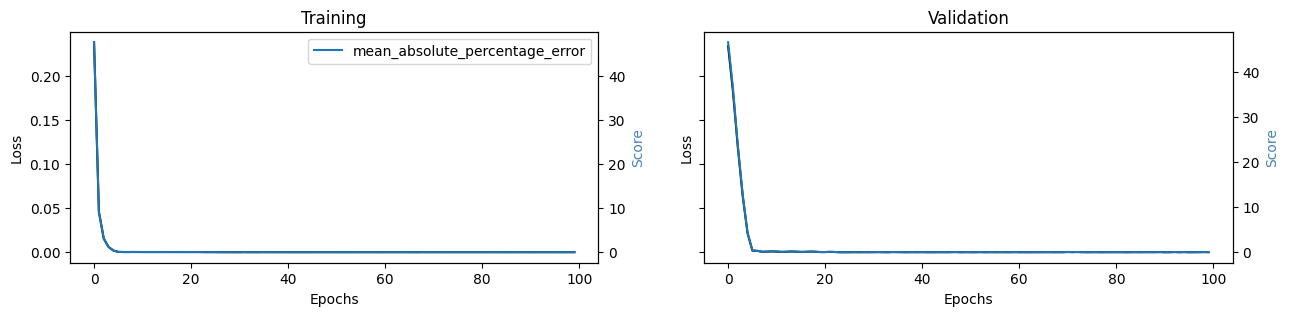

In [36]:
training = model.fit(x=[train["user"], train["product"]], y=train["y"], 
                     epochs=100, batch_size=128, shuffle=True, verbose=0, validation_split=0.3)
model = training.model
utils_plot_keras_training(training)

In [37]:
test["yhat"] = model.predict([test["user"], test["product"]])
test

641/641 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step


,user,product,y,yhat
0,0,2019,0.5,0.499948
1,0,2025,0.5,0.499985
2,0,2075,0.5,0.499991
3,0,2101,0.5,0.499845
4,0,2105,0.5,0.499872
...,...,...,...,...
20493,499,2459,0.5,0.499935
20494,499,2465,0.5,0.499912
20495,499,2470,0.5,0.499961
20496,499,2479,0.5,0.499820


**Avaliação**

In [38]:
y_test = test["y"]
predicted = test["yhat"]

print("Mean Absolute Error (Σ|y-pred|/n):", "{:,.0f}".format(metrics.mean_absolute_error(y_test, predicted)))
print("Mean Absolute Perc Error (Σ(|y-pred|/y)/n):", str(round(np.mean(np.abs((y_test-predicted)/predicted)), 2))+"%") # Diferença entre os valores testados e os predicted

Mean Absolute Error (Σ|y-pred|/n): 0
Mean Absolute Perc Error (Σ(|y-pred|/y)/n): 0.0%


**Criação de métricas de avalição com diferentes tamanhos de y_test e predicted, num user em específico**

In [39]:
i = users_max_aux
print("--- user", i, "---")

lA=[]
lR=[]
lP=[]
lrr=[]

x=range(1,x_value)

for j in x:
    top = j
    y_test = test[test["user"]==i].sort_values("y", ascending=False)["product"].values[:top]
    #print("y_test:", y_test)

    predicted = test[test["user"]==i].sort_values("yhat", ascending=False)["product"].values[:top]
    #print("predicted:", predicted)

    y_test_set = set(y_test)
    predicted_set = set(predicted)

    true_positive = len(y_test_set & predicted_set)

    false_negative = len(y_test_set - predicted_set)

    false_positive = len(predicted_set - y_test_set)
    #Accuracy
    accuracy = (true_positive / top)*100

    # Recall
    recall = (true_positive / (true_positive + false_negative))*100

    # Precision
    precision = true_positive / (true_positive + false_positive)*100

    lA.append(accuracy)
    lR.append(recall)
    lP.append(precision)
    lrr.append(round(mean_reciprocal_rank(y_test, predicted),2))

    if accuracy == 100:
        if recall == 100:
            if precision == 100:
                print('Valor que chegou a 100%: '+str(j))
    
def accVM():
    top = test_len
    y_test = test[test["user"]==i].sort_values("y", ascending=False)["product"].values[:top]
    predicted = test[test["user"]==i].sort_values("yhat", ascending=False)["product"].values[:top]
    y_test_set = set(y_test)
    predicted_set = set(predicted)
    true_positive = len(y_test_set & predicted_set)
    accuracyVM = (true_positive / top)*100
    print("accuracy do valor médio de x:",str(round(accuracyVM,2))+'%')
    return accuracyVM,top


print("accuracy:", str(round(metrics.accuracy_score(y_test,predicted)*100,1))+"%")
accuracyVM,top = accVM()
print("mrr:", round(mean_reciprocal_rank(y_test, predicted),2))

--- user 31 ---
Valor que chegou a 100%: 96
accuracy: 0.0%
accuracy do valor médio de x: 52.08%
mrr: 0.05


**Resultados obtidos do Model Desing & Testing (Collaborative Filtering)**

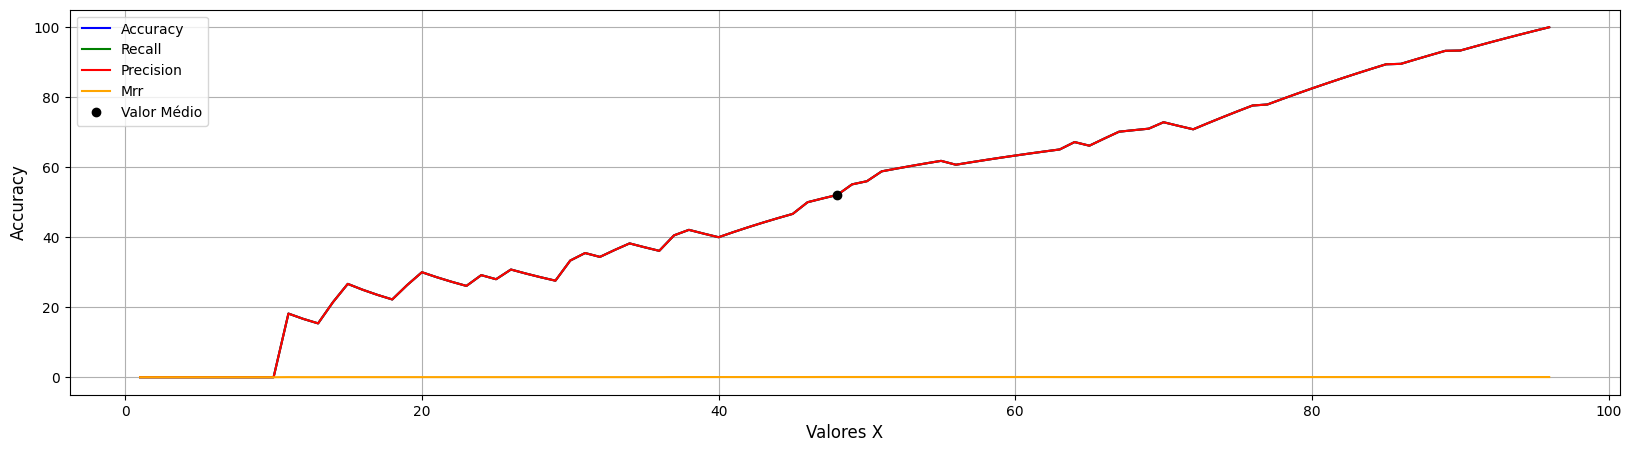

In [40]:
plt.figure(figsize=(20, 5))
plt.plot(x, lA, label="Accuracy", color="blue")  
plt.plot(x, lR, label="Recall", color="green")  
plt.plot(x, lP, label="Precision", color="red")   
plt.plot(x, lrr, label="Mrr", color="orange")
plt.plot(top,accuracyVM,'bo',color='black',label="Valor Médio")
plt.xlabel("Valores X", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y')
plt.grid(axis='x')
plt.legend()
plt.show()

**Identificação das músicas e respetivas informações**

In [41]:
test[test["user"]==i].merge(
        dtf_products[["name","old","genres"]], left_on="product", right_index=True
    ).sort_values("yhat", ascending=False)

,user,product,y,yhat,name,old,genres
1217,31,2464,0.5,0.500121,Questão de Tempo,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
1166,31,2197,0.5,0.500088,See You Again (feat. Charlie Puth),1,chicago-house|club|dance|dancehall|garage|house
1211,31,2433,0.5,0.500083,Si Te Dijeron,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
1178,31,2271,0.5,0.500080,Let There Be Sodomy,0,alternative metal|black-metal|death-metal|grin...
1198,31,2374,0.5,0.500079,Mud,1,chicago-house|club|dance|dancehall|garage|house
...,...,...,...,...,...,...,...
1177,31,2264,0.5,0.499804,"Blue On Black (feat. Kenny Wayne Shepherd, Bra...",1,ambient|bluegrass|groove|jazz|piano
1215,31,2454,0.5,0.499795,Dancin (feat. Luvli) - Philip George Remix,1,chicago-house|club|dance|dancehall|garage|house
1192,31,2351,0.5,0.499774,I Saw Mommy Kissing Santa Claus,0,blues|funk|r-n-b|soul
1183,31,2295,0.5,0.499763,Ciało me wklęte,0,alternative metal|black-metal|death-metal|grin...


**Gráfico de análise do rating real com o previsto**

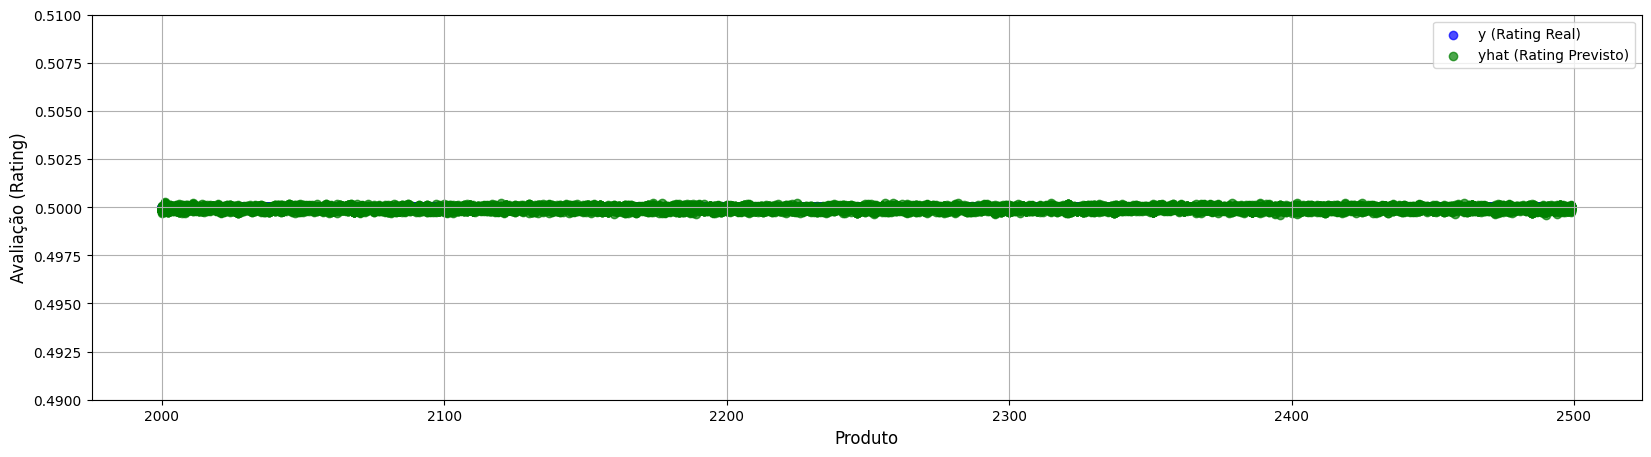

In [42]:
plt.figure(figsize=(20, 5))
plt.scatter(test['product'], test['y'], label='y (Rating Real)', color="blue", alpha=0.7)
plt.scatter(test['product'], test['yhat'], label='yhat (Rating Previsto)', color="green", alpha=0.7)
plt.ylim(0.49, 0.51)
plt.xlabel("Produto", fontsize=12)
plt.ylabel("Avaliação (Rating)", fontsize=12)
plt.grid()
plt.legend()
plt.show()

### 5 - Model Desing & Testing (Neural Collaborative Filtering)

**Data**

In [43]:
train = dtf_train.stack(dropna=True).reset_index().rename(columns={0:"y"})
train.head()

,user,product,y
0,0,11,0.5
1,0,45,0.5
2,0,90,0.5
3,0,99,0.5
4,0,126,0.5


In [44]:
test = dtf_test.stack(dropna=True).reset_index().rename(columns={0:"y"})
test.head()

,user,product,y
0,0,2019,0.5
1,0,2025,0.5
2,0,2075,0.5
3,0,2101,0.5
4,0,2105,0.5


**Criação do design do modelo**

In [45]:
embeddings_size = 50
usr, prd = dtf_users.shape[0], dtf_users.shape[1]

# Input layer
xusers_in = layers.Input(name="xusers_in", shape=(1,))
xproducts_in = layers.Input(name="xproducts_in", shape=(1,))

# A) Matrix Factorization
## embeddings and reshape
cf_xusers_emb = layers.Embedding(name="cf_xusers_emb", input_dim=usr, output_dim=embeddings_size)(xusers_in)
cf_xusers = layers.Reshape(name='cf_xusers', target_shape=(embeddings_size,))(cf_xusers_emb)
## embeddings and reshape
cf_xproducts_emb = layers.Embedding(name="cf_xproducts_emb", input_dim=prd, output_dim=embeddings_size)(xproducts_in)
cf_xproducts = layers.Reshape(name='cf_xproducts', target_shape=(embeddings_size,))(cf_xproducts_emb)
## product
cf_xx = layers.Dot(name='cf_xx', normalize=True, axes=1)([cf_xusers, cf_xproducts])

# B) Neural Network
## embeddings and reshape
nn_xusers_emb = layers.Embedding(name="nn_xusers_emb", input_dim=usr, output_dim=embeddings_size)(xusers_in)
nn_xusers = layers.Reshape(name='nn_xusers', target_shape=(embeddings_size,))(nn_xusers_emb)
## embeddings and reshape
nn_xproducts_emb = layers.Embedding(name="nn_xproducts_emb", input_dim=prd, output_dim=embeddings_size)(xproducts_in)
nn_xproducts = layers.Reshape(name='nn_xproducts', target_shape=(embeddings_size,))(nn_xproducts_emb)
## concat and dense
nn_xx = layers.Concatenate()([nn_xusers, nn_xproducts])
nn_xx = layers.Dense(name="nn_xx", units=int(embeddings_size/2), activation='relu')(nn_xx)

# Merge A & B
y_out = layers.Concatenate()([cf_xx, nn_xx])
y_out = layers.Dense(name="y_out", units=1, activation='linear')(y_out)

# Compile
model = models.Model(inputs=[xusers_in,xproducts_in], outputs=y_out, name="Neural_CollaborativeFiltering")
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mean_absolute_percentage_error'])
model.summary()

Model: "Neural_CollaborativeFiltering"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xusers_in           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xproducts_in        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xusers_emb       │ (None, 1, 50)     │     25,000 │ xusers_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xproducts_emb    │ (None, 1, 50)     │    125,000 │ xproducts_in[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xusers_emb       │ (None, 1, 50)     │     25,000 │ xusers_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xproducts_emb    │ (None, 1, 50)     │    125,000 │ xproducts_in[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xusers (Reshape) │ (None, 50)        │          0 │ nn_xusers_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xproducts        │ (None, 50)        │          0 │ nn_xproducts_emb… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xusers (Reshape) │ (None, 50)        │          0 │ cf_xusers_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xproducts        │ (None, 50)        │          0 │ cf_xproducts_emb… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ nn_xusers[0][0],  │
│ (Concatenate)       │                   │            │ nn_xproducts[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xx (Dot)         │ (None, 1)         │          0 │ cf_xusers[0][0],  │
│                     │                   │            │ cf_xproducts[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xx (Dense)       │ (None, 25)        │      2,525 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 26)        │          0 │ cf_xx[0][0],      │
│ (Concatenate)       │                   │            │ nn_xx[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_out (Dense)       │ (None, 1)         │         27 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 302,552 (1.15 MB)

 Trainable params: 302,552 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

**Gráfico de Combinação não linear apartir de uma Neural Network e uma matriz de fatorização para criar as matrizes de users e products**

In [438]:
utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


**Treino e Teste**

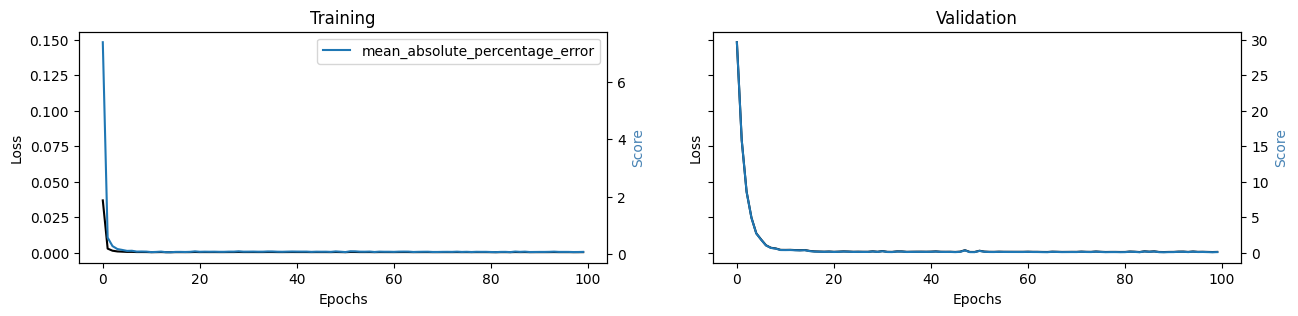

In [46]:
training = model.fit(x=[train["user"], train["product"]], y=train["y"], 
                     epochs=100, batch_size=128, shuffle=True, verbose=0, validation_split=0.3)
model = training.model
utils_plot_keras_training(training)

In [47]:
test["yhat"] = model.predict([test["user"], test["product"]])
test

641/641 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,user,product,y,yhat
0,0,2019,0.5,0.500731
1,0,2025,0.5,0.500547
2,0,2075,0.5,0.500626
3,0,2101,0.5,0.500392
4,0,2105,0.5,0.500320
...,...,...,...,...
20493,499,2459,0.5,0.502338
20494,499,2465,0.5,0.500059
20495,499,2470,0.5,0.500325
20496,499,2479,0.5,0.500094


**Avaliação**

In [48]:
y_test = test["y"]
predicted = test["yhat"]

print("Mean Absolute Error (Σ|y-pred|/n):", "{:,.0f}".format(metrics.mean_absolute_error(y_test, predicted)))
print("Mean Absolute Perc Error (Σ(|y-pred|/y)/n):", str(round(np.mean(np.abs((y_test-predicted)/predicted)), 2))+"%") # Diferença entre os valores testados e os predicted

Mean Absolute Error (Σ|y-pred|/n): 0
Mean Absolute Perc Error (Σ(|y-pred|/y)/n): 0.0%


**Criação de métricas de avalição com diferentes tamanhos de y_test e predicted, num user em específico**

In [49]:
i = users_max_aux
print("--- user", i, "---")

lA=[]
lR=[]
lP=[]
lrr=[]

x=range(1,x_value)

for j in x:
    top = j
    y_test = test[test["user"]==i].sort_values("y", ascending=False)["product"].values[:top]
    #print("y_test:", y_test)

    predicted = test[test["user"]==i].sort_values("yhat", ascending=False)["product"].values[:top]
    #print("predicted:", predicted)

    y_test_set = set(y_test)
    predicted_set = set(predicted)

    true_positive = len(y_test_set & predicted_set)

    false_negative = len(y_test_set - predicted_set)  

    false_positive = len(predicted_set - y_test_set)

    #Accuracy
    accuracy = (true_positive / top)*100

    # Recall
    recall = (true_positive / (true_positive + false_negative))*100

    # Precision
    precision = true_positive / (true_positive + false_positive)*100

    lA.append(accuracy)
    lR.append(recall)
    lP.append(precision)
    lrr.append(round(mean_reciprocal_rank(y_test, predicted),2))

    if accuracy == 100:
        if recall == 100:
            if precision == 100:
                print('Valor que chegou a 100%: '+str(j))

def accVM():
    top = test_len
    y_test = test[test["user"]==i].sort_values("y", ascending=False)["product"].values[:top]
    predicted = test[test["user"]==i].sort_values("yhat", ascending=False)["product"].values[:top]
    y_test_set = set(y_test)
    predicted_set = set(predicted)
    true_positive = len(y_test_set & predicted_set)
    accuracyVM = (true_positive / top)*100
    print("accuracy do valor médio de x:",str(round(accuracyVM,2))+'%')
    return accuracyVM,top


print("accuracy:", str(round(metrics.accuracy_score(y_test,predicted)*100,2))+"%")
accuracyVM,top = accVM()
print("mrr:", round(mean_reciprocal_rank(y_test, predicted),2))

--- user 31 ---
Valor que chegou a 100%: 96
accuracy: 0.0%
accuracy do valor médio de x: 50.0%
mrr: 0.05


**Resultados obtidos do Model Desing & Testing (Neural Collaborative Filtering)**

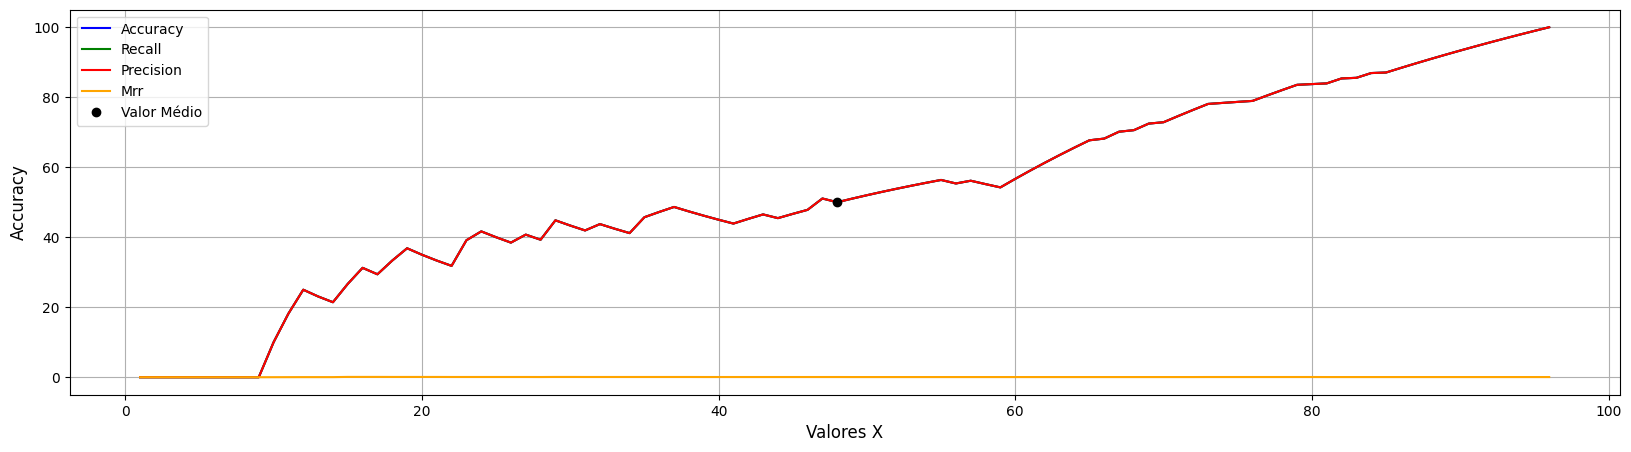

In [50]:
plt.figure(figsize=(20, 5))
plt.plot(x, lA, label="Accuracy", color="blue")  
plt.plot(x, lR, label="Recall", color="green")  
plt.plot(x, lP, label="Precision", color="red")   
plt.plot(x, lrr, label="Mrr", color="orange")
plt.plot(top,accuracyVM,'bo',color='black',label="Valor Médio")
plt.xlabel("Valores X", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y')
plt.grid(axis='x')
plt.legend()
plt.show()

**Identificação das músicas e respetivas informações**

In [51]:
test[test["user"]==i].merge(
        dtf_products[["name","old","genres"]], left_on="product", right_index=True
    ).sort_values("yhat", ascending=False)

,user,product,y,yhat,name,old,genres
1194,31,2361,0.5,0.501782,Plage À Trois,0,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
1201,31,2389,0.5,0.501571,Ay Que Borrachera,0,blues|funk|r-n-b|soul
1135,31,2052,0.5,0.501364,Kathy's Song (Come Lie Next To Me),1,alternative metal|black-metal|death-metal|grin...
1144,31,2108,0.5,0.501326,Strawberries & Cigarettes,0,chicago-house|club|dance|dancehall|garage|house
1197,31,2366,0.5,0.501277,Confessions of a Blackheart,0,alternative metal|black-metal|death-metal|grin...
...,...,...,...,...,...,...,...
1221,31,2473,0.5,0.500106,La Cecilia,1,blues|funk|r-n-b|soul
1171,31,2237,0.5,0.500084,November,1,ambient|bluegrass|groove|jazz|piano
1204,31,2394,0.5,0.500021,Third Day Of A Seven Day Binge,1,alternative metal|black-metal|death-metal|grin...
1210,31,2425,0.5,0.499929,Tree Of Life,0,ambient|bluegrass|groove|jazz|piano


**Gráfico de análise do rating real com o previsto**

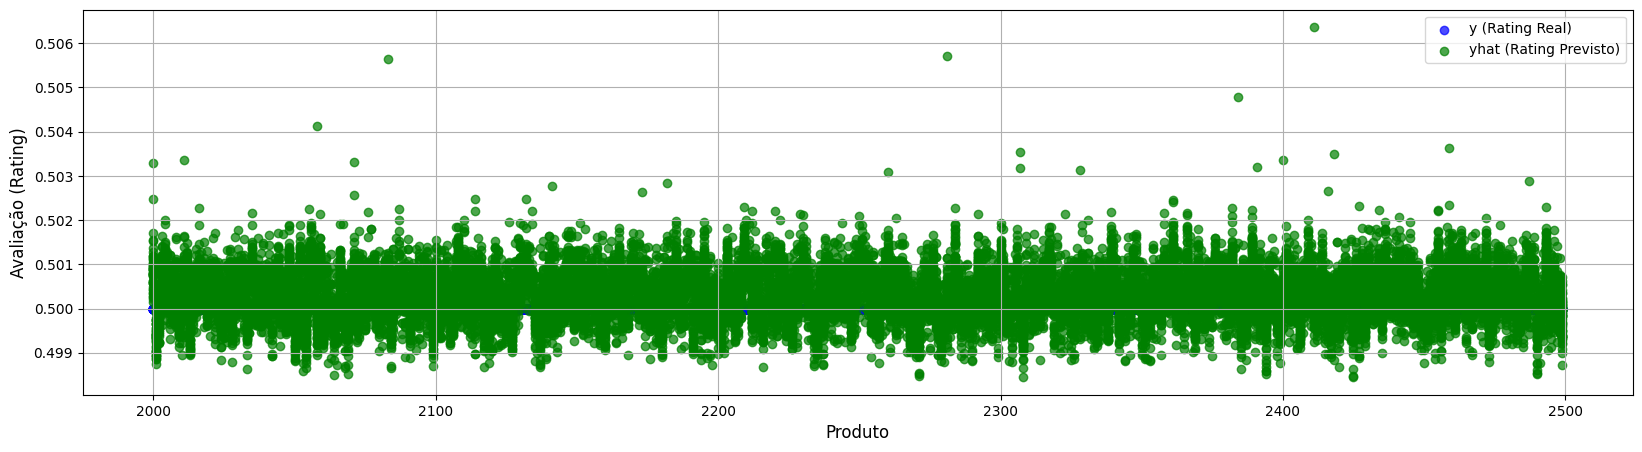

In [52]:
plt.figure(figsize=(20, 5))
plt.scatter(test['product'], test['y'], label='y (Rating Real)', color="blue", alpha=0.7)
plt.scatter(test['product'], test['yhat'], label='yhat (Rating Previsto)', color="green", alpha=0.7)
plt.xlabel("Produto", fontsize=12)
plt.ylabel("Avaliação (Rating)", fontsize=12)
plt.grid()
plt.legend()
plt.show()

### 6 - Hybrid Model

**Data**

In [53]:
features = dtf_products.drop(["genres","name"], axis=1).columns
print(features)

context = dtf_context.drop(["user","product"], axis=1).columns
print(context)

Index(['old', 'happy', 'dance rock', 'dutch cabaret', 'goth', 'dance pop',
       'r-n-b', 'latin', 'hard-rock', 'guitar',
       ...
       'romance', 'salsa', 'heavy-metal', 'piano', 'comedy', 'club',
       'album rock', 'party', 'sad', 'synth-pop'],
      dtype='object', length=126)
Index(['daytime', 'weekend'], dtype='object')


In [54]:
train = dtf_train.stack(dropna=True).reset_index().rename(columns={0:"y"})

## add features
train = train.merge(dtf_products[features], how="left", left_on="product", right_index=True)

## add context
train = train.merge(dtf_context, how="left")

train.head()

,user,product,y,old,happy,dance rock,dutch cabaret,goth,dance pop,r-n-b,...,heavy-metal,piano,comedy,club,album rock,party,sad,synth-pop,daytime,weekend
0,0,11,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,0,45,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,90,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
3,0,90,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,99,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [55]:
test = dtf_test.stack(dropna=True).reset_index().rename(columns={0:"y"})

## add features
test = test.merge(dtf_products.drop(["genres","name"], axis=1), how="left", left_on="product", right_index=True)

## add context
test[context] = 0 #--> simulate production for a weekday night
#test = test.merge(dtf_context, how="left") #--> use test set

test.head()

,user,product,y,old,happy,dance rock,dutch cabaret,goth,dance pop,r-n-b,...,heavy-metal,piano,comedy,club,album rock,party,sad,synth-pop,daytime,weekend
0,0,2019,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,2025,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2075,0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,2101,0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2105,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Criação do design do modelo**

In [56]:
embeddings_size = 50
usr, prd = dtf_users.shape[0], dtf_users.shape[1]
feat = len(features)
ctx = len(context)

########################################## COLLABORATIVE FILTERING ###################################################
# Input layer
xusers_in = layers.Input(name="xusers_in", shape=(1,))
xproducts_in = layers.Input(name="xproducts_in", shape=(1,))

# A) Matrix Factorization
## embeddings and reshape
cf_xusers_emb = layers.Embedding(name="cf_xusers_emb", input_dim=usr, output_dim=embeddings_size)(xusers_in)
cf_xusers = layers.Reshape(name='cf_xusers', target_shape=(embeddings_size,))(cf_xusers_emb)
## embeddings and reshape
cf_xproducts_emb = layers.Embedding(name="cf_xproducts_emb", input_dim=prd, output_dim=embeddings_size)(xproducts_in)
cf_xproducts = layers.Reshape(name='cf_xproducts', target_shape=(embeddings_size,))(cf_xproducts_emb)
## product
cf_xx = layers.Dot(name='cf_xx', normalize=True, axes=1)([cf_xusers, cf_xproducts])

# B) Neural Network
## embeddings and reshape
nn_xusers_emb = layers.Embedding(name="nn_xusers_emb", input_dim=usr, output_dim=embeddings_size)(xusers_in)
nn_xusers = layers.Reshape(name='nn_xusers', target_shape=(embeddings_size,))(nn_xusers_emb)
## embeddings and reshape
nn_xproducts_emb = layers.Embedding(name="nn_xproducts_emb", input_dim=prd, output_dim=embeddings_size)(xproducts_in)
nn_xproducts = layers.Reshape(name='nn_xproducts', target_shape=(embeddings_size,))(nn_xproducts_emb)
## concat and dense
nn_xx = layers.Concatenate()([nn_xusers, nn_xproducts])
nn_xx = layers.Dense(name="nn_xx", units=int(embeddings_size/2), activation='relu')(nn_xx)

########################################## CONTENT BASED ###################################################
# Product Features
features_in = layers.Input(name="features_in", shape=(feat,))
features_x = layers.Dense(name="features_x", units=feat, activation='relu')(features_in)

########################################## KNOWLEDGE BASED #################################################
# Context
contexts_in = layers.Input(name="contexts_in", shape=(ctx,))
context_x = layers.Dense(name="context_x", units=ctx, activation='relu')(contexts_in)

########################################## OUTPUT ###################################################
# Merge all
y_out = layers.Concatenate()([cf_xx, nn_xx, features_x, context_x])
y_out = layers.Dense(name="y_out", units=1, activation='linear')(y_out)

# Compile
model = models.Model(inputs=[xusers_in,xproducts_in, features_in, contexts_in], outputs=y_out, name="Hybrid_Model")
model.compile(optimizer='adam', loss='mean_absolute_error', metrics=['mean_absolute_percentage_error'])
model.summary()

Model: "Hybrid_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xusers_in           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xproducts_in        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xusers_emb       │ (None, 1, 50)     │     25,000 │ xusers_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xproducts_emb    │ (None, 1, 50)     │    125,000 │ xproducts_in[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xusers_emb       │ (None, 1, 50)     │     25,000 │ xusers_in[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xproducts_emb    │ (None, 1, 50)     │    125,000 │ xproducts_in[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xusers (Reshape) │ (None, 50)        │          0 │ nn_xusers_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xproducts        │ (None, 50)        │          0 │ nn_xproducts_emb… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xusers (Reshape) │ (None, 50)        │          0 │ cf_xusers_emb[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xproducts        │ (None, 50)        │          0 │ cf_xproducts_emb… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 100)       │          0 │ nn_xusers[0][0],  │
│ (Concatenate)       │                   │            │ nn_xproducts[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_in         │ (None, 126)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ contexts_in         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_xx (Dot)         │ (None, 1)         │          0 │ cf_xusers[0][0],  │
│                     │                   │            │ cf_xproducts[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nn_xx (Dense)       │ (None, 25)        │      2,525 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ features_x (Dense)  │ (None, 126)       │     16,002 │ features_in[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_x (Dense)   │ (None, 2)         │          6 │ contexts_in[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 154)       │          0 │ cf_xx[0][0],      │
│ (Concatenate)       │                   │            │ nn_xx[0][0],      │
│                     │                   │            │ features_x[0][0]

 Total params: 318,688 (1.22 MB)

 Trainable params: 318,688 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

**Gráfico de Neural Collaborative Filtering Network Structure que incluí matrizes de users-products, géneros e contexto**

In [450]:
utils.plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


**Treino e Teste**

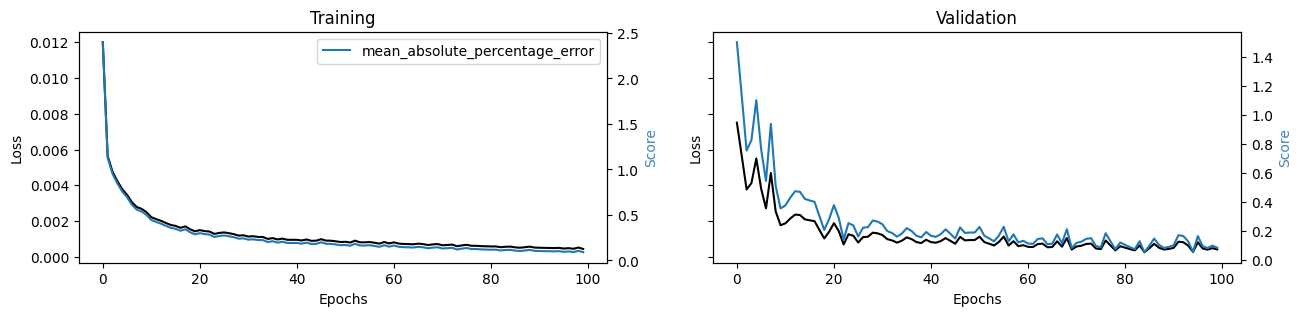

In [57]:
training = model.fit(x=[train["user"], train["product"], train[features], train[context]], y=train["y"], 
                     epochs=100, batch_size=128, shuffle=True, verbose=0, validation_split=0.3)

model = training.model
utils_plot_keras_training(training)

In [58]:
test["yhat"] = model.predict([test["user"], test["product"], test[features], test[context]])
test

641/641 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


,user,product,y,old,happy,dance rock,dutch cabaret,goth,dance pop,r-n-b,...,piano,comedy,club,album rock,party,sad,synth-pop,daytime,weekend,yhat
0,0,2019,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.500462
1,0,2025,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.500553
2,0,2075,0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.500259
3,0,2101,0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.500191
4,0,2105,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.500482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20493,499,2459,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.499858
20494,499,2465,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.499771
20495,499,2470,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.499835
20496,499,2479,0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.499805


**Avaliação**

In [59]:
y_test = test["y"]
predicted = test["yhat"]

print("Mean Absolute Error (Σ|y-pred|/n):", "{:,.0f}".format(metrics.mean_absolute_error(y_test, predicted)))
print("Mean Absolute Perc Error (Σ(|y-pred|/y)/n):", str(round(np.mean(np.abs((y_test-predicted)/predicted)), 2))+"%") # Diferença entre os valores testados e os predicted

Mean Absolute Error (Σ|y-pred|/n): 0
Mean Absolute Perc Error (Σ(|y-pred|/y)/n): 0.0%


**Criação de métricas de avalição com diferentes tamanhos de y_test e predicted, num user em específico**

In [60]:
i = users_max_aux
print("--- user", i, "---")

lA=[]
lR=[]
lP=[]
lrr=[]

x=range(1,x_value)

for j in x:
    top = j

    y_test = test[test["user"]==i].sort_values("y", ascending=False)["product"].values[:top]
    #print("y_test:", y_test)

    predicted = test[test["user"]==i].sort_values("yhat", ascending=False)["product"].values[:top]
    #print("predicted:", predicted)

    y_test_set = set(y_test)
    predicted_set = set(predicted)

    true_positive = len(y_test_set & predicted_set)  # Interseção

    false_negative = len(y_test_set - predicted_set)  # Diferença

    false_positive = len(predicted_set - y_test_set)  # Diferença

    #Accuracy
    accuracy = (true_positive / top)*100

    # Recall
    recall = (true_positive / (true_positive + false_negative))*100

    # Precision
    precision = true_positive / (true_positive + false_positive)*100

    lA.append(accuracy)
    lR.append(recall)
    lP.append(precision)
    lrr.append(round(mean_reciprocal_rank(y_test, predicted),2))

    if accuracy == 100:
        if recall == 100:
            if precision == 100:
                print('Valor que chegou a 100%: '+str(j))


def accVM():
    top = test_len
    y_test = test[test["user"]==i].sort_values("y", ascending=False)["product"].values[:top]
    predicted = test[test["user"]==i].sort_values("yhat", ascending=False)["product"].values[:top]
    y_test_set = set(y_test)
    predicted_set = set(predicted)
    true_positive = len(y_test_set & predicted_set)
    accuracyVM = (true_positive / top)*100
    print("accuracy do valor médio de x:",str(round(accuracyVM,2))+'%')
    return accuracyVM,top


print("accuracy:", str(round(metrics.accuracy_score(y_test,predicted)*100,1))+"%")
accuracyVM,top = accVM()
print("mrr:", round(mean_reciprocal_rank(y_test, predicted),2))

--- user 31 ---
Valor que chegou a 100%: 95
Valor que chegou a 100%: 96
accuracy: 3.1%
accuracy do valor médio de x: 50.0%
mrr: 0.05


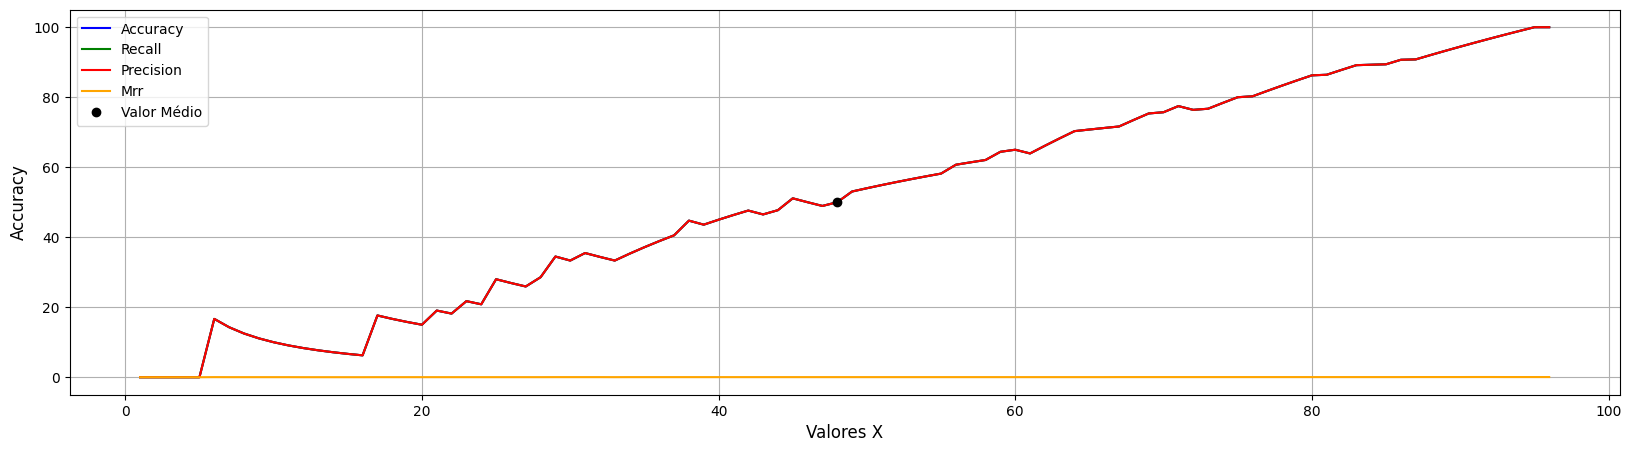

In [61]:
plt.figure(figsize=(20, 5))
plt.plot(x, lA, label="Accuracy", color="blue")  
plt.plot(x, lR, label="Recall", color="green")
plt.plot(x, lP, label="Precision", color="red")   
plt.plot(x, lrr, label="Mrr", color="orange")
plt.plot(top,accuracyVM,'bo',color='black',label="Valor Médio")
plt.xlabel("Valores X", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(axis='y')
plt.grid(axis='x')
plt.legend()
plt.show()

**Identificação das músicas e respetivas informações**

In [62]:
test[test["user"]==i].merge(
        dtf_products[["name","old","genres"]], left_on="product", right_index=True
    ).sort_values("yhat", ascending=False)

,user,product,y,old_x,happy,dance rock,dutch cabaret,goth,dance pop,r-n-b,...,album rock,party,sad,synth-pop,daytime,weekend,yhat,name,old_y,genres
1167,31,2200,0.5,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0.500417,Safari Song,1,blues|funk|r-n-b|soul
1174,31,2248,0.5,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0.500380,MEGAFUNK GREEN VALEY,1,blues|funk|r-n-b|soul
1138,31,2085,0.5,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0.500379,Envolver,1,blues|funk|r-n-b|soul
1133,31,2032,0.5,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0.500333,Flippity Flop Flop,1,blues|funk|r-n-b|soul
1221,31,2473,0.5,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0.500329,La Cecilia,1,blues|funk|r-n-b|soul
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1214,31,2448,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0.498423,Vaqueiro É Pressão,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
1182,31,2291,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0.498415,Bom Dia Vietnã,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
1152,31,2136,0.5,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0.498412,Chora De Tabela - Ao Vivo,1,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...
1184,31,2310,0.5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.498408,Se Tiver Coragem Joga Fora,0,brazil|forro|latin|mpb|pagode|reggaeton|salsa|...


**Gráfico de análise do rating real com o previsto**

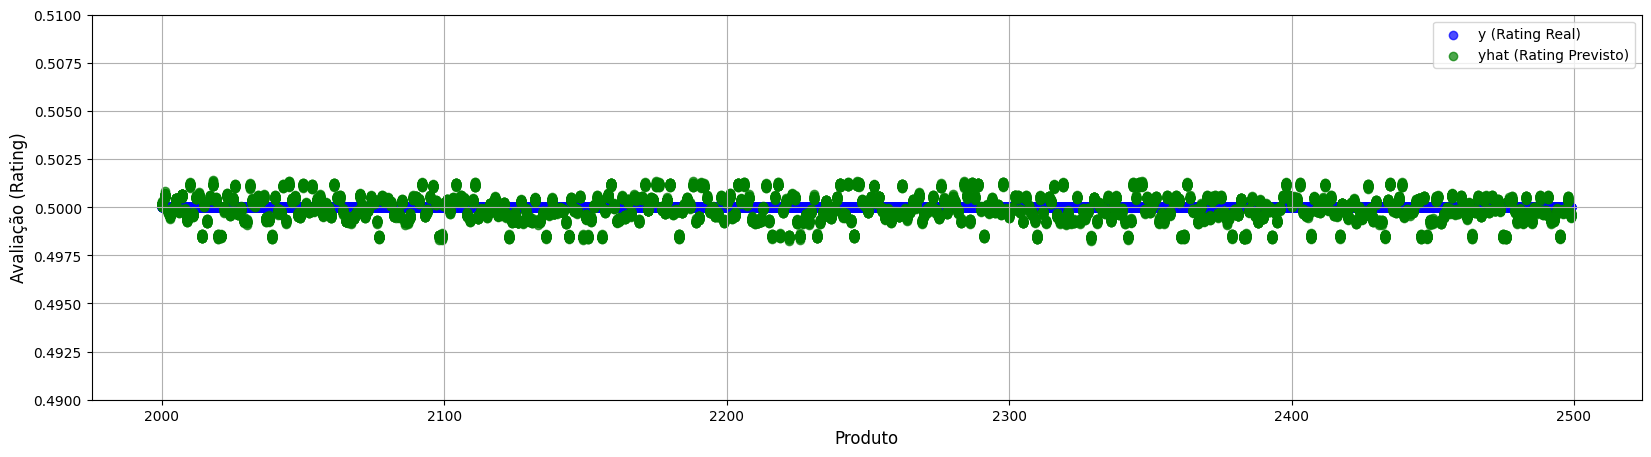

In [63]:
plt.figure(figsize=(20, 5))
plt.scatter(test['product'], test['y'], label='y (Rating Real)', color="blue", alpha=0.7)
plt.scatter(test['product'], test['yhat'], label='yhat (Rating Previsto)', color="green", alpha=0.7)
plt.ylim(0.49, 0.51)
plt.xlabel("Produto", fontsize=12)
plt.ylabel("Avaliação (Rating)", fontsize=12)
plt.grid()
plt.legend()
plt.show()